<a href="https://colab.research.google.com/github/Mar-SHieee/Customer-Rating-Prediction/blob/main/Customer_Rating_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1.Title & Info

**Name:** Mahmoud Elaraby  
**Model:** Model 3 – Customer Rating Prediction (Regression)  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist:"https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce"

## 2. Business Understanding

## Domain

The domain of this project is **E-Commerce**.

The dataset comes from Olist, which is an online marketplace. Customers can buy products from different sellers and then give a review score after receiving their orders.

Customer ratings are important because they can show the customer's satisfaction with the product, delivery, and overall shopping experience.

---

## Model's Problem

The problem of this model is to **predict the customer review score** for an order.

The target variable is:

`review_score`

The review score ranges from **1 to 5**, where:

- 1 = Very Low Rating
- 2 = Low Rating
- 3 = Average Rating
- 4 = Good Rating
- 5 = Excellent Rating

This is a **Regression problem** because the model predicts a numerical value.

The model will use information related to the order, product, payment, seller, and delivery to predict the customer rating.

---

## Why It Matters

Predicting customer ratings can help an e-commerce company understand the factors that affect customer satisfaction.

For example, low ratings may be related to:

- Late delivery
- Long delivery time
- High freight cost
- Product category
- Seller performance

By predicting ratings, the company can identify possible problems and take action before more customers have a negative experience.

This can help improve:

- Customer satisfaction
- Delivery performance
- Seller performance
- Product quality monitoring
- Overall customer experience

---

## Success Criteria

The model will be considered successful if it can predict customer ratings with low prediction errors.

The models will be evaluated using:

- **MAE (Mean Absolute Error)** – lower is better.
- **RMSE (Root Mean Squared Error)** – lower is better.
- **R² Score** – higher is better.

Four regression models will be trained and compared:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. K-Nearest Neighbors Regressor

The best model will be selected based mainly on its performance using **MAE, RMSE, and R² Score**, and then the best model will be tuned using **GridSearchCV**.

## 3. Imports

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
RANDOM_STATE = SEED
np.random.seed(SEED)

## 4. Load Data

In [83]:
customers = pd.read_csv("olist_customers_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
order_payments = pd.read_csv("olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

# Merge Orders with Customers
df = orders.merge(customers,on="customer_id",how="left")

# Merge with Order Items
df = df.merge(order_items,on="order_id",how="left")

# Merge with Products
df = df.merge(products,on="product_id",how="left")

# Merge with Sellers
df = df.merge(sellers,on="seller_id",how="left")

# Merge with Payments
df = df.merge(order_payments,on="order_id",how="left")

# Merge with Reviews
df = df.merge(order_reviews,on="order_id",how="left")

# Merge with category translation
df = df.merge(category_translation,on="product_category_name",how="left")

raw_orders = df.copy()

print('Orders:', orders.shape)
print('Customers:', customers.shape)
print('Items:', order_items.shape)
print('Payments:',order_payments.shape)
print('Products:', products.shape)
print('Sellers:', sellers.shape)
print('Reviews:', order_reviews.shape)
print('full Dataset',df.shape)


Orders: (99441, 8)
Customers: (99441, 5)
Items: (112650, 7)
Payments: (103886, 5)
Products: (32951, 9)
Sellers: (3095, 4)
Reviews: (99224, 7)
full Dataset (119143, 40)


## 5. Data Audit

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

In [85]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,119143,99441,895ab968e7bb0d5659d16cd74cd1650c,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,119143,99441,270c23a11d024a44c896d1894b261a83,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,119143,8,delivered,115723,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,119143,98875,2017-08-08 20:26:31,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_approved_at,118966,90733,2017-08-08 20:43:31,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_carrier_date,117057,81018,2017-08-10 11:58:14,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_customer_date,115722,95664,2017-08-14 12:46:18,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_estimated_delivery_date,119143,459,2017-12-20 00:00:00,663,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,119143,96096,9a736b248f67d166d2fbb006bcb877c3,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,119143.0,NaN,NaN,NaN,35033.451298,29823.198969,1003.0,11250.0,24240.0,58475.0,99990.0


In [86]:
pd.set_option('display.max_columns', None)
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto


In [87]:
pd.set_option('display.max_columns', None)
df.tail(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
119133,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07 00:00:00,c716cf2b5b86fb24257cffe9e7969df8,78048,cuiaba,MT,2.0,49d2e2460386273b195e7e59b43587c3,1caf283236cd69af44cbc09a0a1e7d32,2017-10-10 20:07:14,26.90,36.98,brinquedos,40.0,180.0,3.0,750.0,26.0,15.0,26.0,26020.0,nova iguacu,RJ,2.0,voucher,1.0,64.37,ebd75732b5804e934123d11ec1f11db0,5.0,NaN,NaN,2017-10-21 00:00:00,2017-10-23 14:48:40,toys
119134,aa04ef5214580b06b10e2a378300db44,f01a6bfcc730456317e4081fe0c9940e,delivered,2017-01-27 00:30:03,2017-01-27 01:05:25,2017-01-30 11:40:16,2017-02-07 13:15:25,2017-03-17 00:00:00,e03dbdf5e56c96b106d8115ac336f47f,35502,divinopolis,MG,1.0,9fc063fd34fed29ccc57b7f8e8d03388,ccc4bbb5f32a6ab2b7066a4130f114e3,2017-02-03 00:30:03,370.00,19.43,beleza_saude,48.0,657.0,1.0,750.0,38.0,12.0,25.0,80310.0,curitiba,PR,2.0,voucher,1.0,250.00,e8995c053d3db2d9c07407efe7de52dd,5.0,NaN,NaN,2017-02-08 00:00:00,2017-02-11 12:37:36,health_beauty
119135,aa04ef5214580b06b10e2a378300db44,f01a6bfcc730456317e4081fe0c9940e,delivered,2017-01-27 00:30:03,2017-01-27 01:05:25,2017-01-30 11:40:16,2017-02-07 13:15:25,2017-03-17 00:00:00,e03dbdf5e56c96b106d8115ac336f47f,35502,divinopolis,MG,1.0,9fc063fd34fed29ccc57b7f8e8d03388,ccc4bbb5f32a6ab2b7066a4130f114e3,2017-02-03 00:30:03,370.00,19.43,beleza_saude,48.0,657.0,1.0,750.0,38.0,12.0,25.0,80310.0,curitiba,PR,1.0,credit_card,5.0,139.43,e8995c053d3db2d9c07407efe7de52dd,5.0,NaN,NaN,2017-02-08 00:00:00,2017-02-11 12:37:36,health_beauty
119136,880675dff2150932f1601e1c07eadeeb,47cd45a6ac7b9fb16537df2ccffeb5ac,delivered,2017-02-23 09:05:12,2017-02-23 09:15:11,2017-03-01 10:22:52,2017-03-06 11:08:08,2017-03-22 00:00:00,831ce3f1bacbd424fc4e38fbd4d66d29,5127,sao paulo,SP,1.0,ea73128566d1b082e5101ce46f8107c7,391fc6631aebcf3004804e51b40bcf1e,2017-02-27 09:05:12,139.90,16.09,moveis_decoracao,63.0,254.0,2.0,2500.0,49.0,13.0,41.0,14940.0,ibitinga,SP,1.0,credit_card,3.0,155.99,96e8f371a3983122b739944537e15525,5.0,NaN,NaN,2017-03-07 00:00:00,2017-03-11 15:42:41,furniture_decor
119137,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,1.0,ac35486adb7b02598c182c2ff2e05254,e24fc9fcd865784fb25705606fe3dfe7,2017-03-15 09:54:05,72.00,13.08,beleza_saude,50.0,1517.0,1.0,1175.0,22.0,13.0,18.0,12913.0,braganca paulista,SP,1.0,credit_card,3.0,85.08,e262b3f92d1ce917aa412a9406cf61a6,5.0,NaN,NaN,2017-03-22 00:00:00,2017-03-23 11:02:08,health_beauty
119138,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,1.0,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,bebes,52.0,828.0,4.0,4950.0,40.0,10.0,40.0,17602.0,tupa,SP,1.0,credit_card,3.0,195.00,29bb71b2760d0f876dfa178a76bc4734,4.0,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01,baby
119139,83c1379a015df1e13d02aae0204711ab

In [88]:
missing = pd.DataFrame({
    'count': df.isna().sum(),
    'percent': df.isna().mean().mul(100).round(2)
}).sort_values('percent', ascending=False).sort_values('count', ascending=False)

print('Missing values')
missing


Missing values


,count,percent
review_comment_title,105154,88.26
review_comment_message,68898,57.83
order_delivered_customer_date,3421,2.87
product_category_name_english,2567,2.15
product_description_lenght,2542,2.13
product_name_lenght,2542,2.13
product_photos_qty,2542,2.13
product_category_name,2542,2.13
order_delivered_carrier_date,2086,1.75
review_creation_date,997,0.84


In [89]:
print('Exact duplicate rows:',df.duplicated().sum())
print('Duplicate Order_ID rows:',df.duplicated('order_id', keep=False).sum())

Exact duplicate rows: 0
Duplicate Order_ID rows: 32649


## Hidden nulls problem
there is no hidden nulls in the data as it didn't change after the code

In [90]:
# Detect hidden/misleading null values
hidden_nulls = ['NA', 'N/A', 'Null', 'null', '-', '']

# Replace them with actual missing values
df= df.replace(hidden_nulls, np.nan)

print("Missing values after handling hidden nulls:")
df.isnull().sum().sort_values(ascending=False)

Missing values after handling hidden nulls:


,0
review_comment_title,105155
review_comment_message,68903
order_delivered_customer_date,3421
product_category_name_english,2567
product_description_lenght,2542
product_name_lenght,2542
product_photos_qty,2542
product_category_name,2542
order_delivered_carrier_date,2086
review_creation_date,997


# 6. preprocessing

In [91]:
# Clean column names by snake_case
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

print(df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'product_category_name_english']


In [92]:
# Strip whitespace and unify casing

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()

In [93]:
# Convert date columns to datetime
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "review_creation_date",
    "review_answer_timestamp"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Check data types
print(df[date_columns].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
shipping_limit_date              datetime64[ns]
review_creation_date             datetime64[ns]
review_answer_timestamp          datetime64[ns]
dtype: object


In [94]:
# Convert numeric columns to numeric values
numeric_columns = [
    'price',
    'freight_value',
    'payment_value',
    'payment_installments',
    'payment_sequential'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check data types
print(df[numeric_columns].dtypes)

price                   float64
freight_value           float64
payment_value           float64
payment_installments    float64
payment_sequential      float64
dtype: object


In [95]:
# Convert all object columns to category
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].astype('category')

print(df.dtypes)

order_id                               category
customer_id                            category
order_status                           category
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                     category
customer_zip_code_prefix                  int64
customer_city                          category
customer_state                         category
order_item_id                           float64
product_id                             category
seller_id                              category
shipping_limit_date              datetime64[ns]
price                                   float64
freight_value                           float64
product_category_name                  category
product_name_lenght                     float64
product_description_lenght              

In [96]:
# Check prices and quantity that are less than 0
print("Prices < 0:")
print((df['price'] < 0).sum())
#it is zero so nothing will change

Prices < 0:
0


In [97]:
# Detect discount scale: 0-1 or 0-100

if 'discount' in df.columns:

    discount_max = df['discount'].max()

    print("Maximum discount value:", discount_max)

    if discount_max <= 1:
        print("Discount scale detected: 0-1")

    elif discount_max <= 100:
        print("Discount scale detected: 0-100")

    else:
        print("Warning: Discount values are outside the expected range.")

# Standardize discount to 0-1 scale

if 'discount' in df.columns:

    if df['discount'].max() > 1:
        df['discount'] = df['discount'] / 100

    print(df['discount'].describe())

In [98]:
# Handle missing values

#1.drop the rows with missing values in the review_score column

print(df['review_score'].isnull().sum())
df = df.dropna(subset=['review_score'])
print(df['review_score'].isnull().sum())

# 2. Categorical columns → "Unknown"
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_columns:
    if df[col].isna().any():
        if df[col].dtype.name == 'category':
            df[col] = df[col].cat.add_categories(['Unknown'])

        df[col] = df[col].fillna('Unknown')


# 3. Numeric columns → median
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
  median_value = df[col].median()
  df[col] = df[col].fillna(median_value)

997
0


In [99]:
# Check missing values after handling
print("Missing values after handling:")
print(df.isnull().sum().sum())

Missing values after handling:
6319


In [100]:
missing = pd.DataFrame({
    'count': df.isna().sum(),
    'percent': df.isna().mean().mul(100).round(2)
}).sort_values('percent', ascending=False).sort_values('count', ascending=False)

print('Missing values after handling')
missing

Missing values after handling


,count,percent
order_delivered_customer_date,3285,2.78
order_delivered_carrier_date,2048,1.73
shipping_limit_date,814,0.69
order_approved_at,172,0.15
order_purchase_timestamp,0,0.00
order_status,0,0.00
customer_id,0,0.00
order_id,0,0.00
order_estimated_delivery_date,0,0.00
customer_unique_id,0,0.00


In [101]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "review_creation_date",
    "review_answer_timestamp"
]

for col in date_columns:
    df[col] =df[col] = df[col].fillna('Unknown')

print(df.isnull().sum().sum())

0


In [102]:
numeric_columns = [
     'price',
    'freight_value',
    'payment_value',
    'payment_installments',
    'payment_sequential'
]
for col in numeric_columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = ((df[col] < lower) | (df[col] > upper)).sum()

        print(f'{col}')
        print(f'Lower limit: {lower:.2f}')
        print(f'Upper limit: {upper:.2f}')
        print(f'Number of outliers: {outliers}')
        print()

#Outlier treatment: Numerical variables were checked using the IQR method. Extreme values were not automatically removed because high prices and
# freight values can represent legitimate e-commerce transactions. Only clearly invalid values, such as non-positive prices, were removed.

price
Lower limit: -99.39
Upper limit: 272.05
Number of outliers: 8893

freight_value
Lower limit: 0.98
Upper limit: 33.25
Number of outliers: 12685

payment_value
Lower limit: -131.68
Upper limit: 381.41
Number of outliers: 9540

payment_installments
Lower limit: -3.50
Upper limit: 8.50
Number of outliers: 8050

payment_sequential
Lower limit: 1.00
Upper limit: 1.00
Number of outliers: 5104



# 7. Feature Engeneering

In [103]:
df["review_score"].value_counts()

,count
review_score,
5.0,66343
4.0,22319
1.0,15428
3.0,9894
2.0,4162


# 📅 Date-Based Feature Engineering

To improve the model's ability to predict customer ratings, several time-related features were extracted from the original timestamp columns. These features help capture customer behavior, delivery performance, and seasonal patterns.

## Order Lifecycle & Timestamps

```text
[Customer places order]
       │
       ▼
order_purchase_timestamp
       │
       ▼
[Store approves order]
       │
       ▼
order_approved_at
       │
       ▼
[Seller hands package to carrier]
       │
       ▼
order_delivered_carrier_date
       │
       ▼
[Carrier delivers package to customer]
       │
       ▼
order_delivered_customer_date
       │
       ▼
[Expected delivery date target]
       │
       ▼
order_estimated_delivery_date

## **delivery_days = actual_delivery_date - purchase_date**
The total number of days between the purchase date and the actual delivery date,
This feature measures how long customers had to wait to receive their orders.

In [104]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], errors="coerce")
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"], errors="coerce")

df["delivery_days"] = (
    df["order_delivered_customer_date"]
    - df["order_purchase_timestamp"]
).dt.days

## **expected_delivery_days = estimated_delivery_date - purchase_date**
The number of days the company originally expected the delivery process to take,
This feature represents the company's promised delivery time.

In [105]:
df["expected_delivery_days"] = (
    df["order_estimated_delivery_date"]
    - df["order_purchase_timestamp"]
).dt.days

## **delivery_delay_days = actual_delivery_days - expected_delivery_days**
The difference between the actual delivery time and the expected delivery time,
This feature directly measures delivery performance.

In [106]:
df["delivery_delay_days"] = (
    df["delivery_days"]
    - df["expected_delivery_days"]
)

## **is_delayed: A binary feature that indicates whether an order was delivered late**
This feature simplifies delivery performance into a yes/no variable.

In [107]:
df["is_delayed"] = (df["delivery_delay_days"] > 0).astype(int)

In [108]:
df["is_delayed"].value_counts()

,count
is_delayed,
0,109875
1,8271


## Delayed orders received an average rating of 2.50, compared with 4.14 for on-time orders. This suggests that delivery performance is one of the strongest factors affecting customer satisfaction.

In [109]:
df.groupby("is_delayed")["review_score"].mean()

,review_score
is_delayed,
0,4.133943
1,2.443235


## **The month when the order was placed.**
Customer satisfaction may be influenced by seasonal trends.

In [110]:
df["purchase_month"] = (
    df["order_purchase_timestamp"]
    .dt.month
)

## 0	Monday
## 1	Tuesday
## 2	Wednesday
## 3	Thursday
## 4	Friday
## 5	Saturday
## 6	Sunday

In [111]:
df["purchase_weekday"] = (
    df["order_purchase_timestamp"]
    .dt.dayofweek
)

## **The hour when the customer placed the order**

In [112]:
df["purchase_hour"] = (
    df["order_purchase_timestamp"]
    .dt.hour
)

## **A binary feature that indicates whether the order was placed during the weekend**

In [113]:
df["is_weekend"] = (
    df["purchase_weekday"]
    .isin([5, 6])
    .astype(int)
)

## The day of the week had little effect on customer ratings. Average ratings remained relatively stable across all days, suggesting that purchase timing was not a significant factor affecting customer satisfaction.

In [114]:
weekday_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

(
    df.groupby("purchase_weekday")["review_score"]
    .mean()
    .rename(index=weekday_names)
    .sort_index()
)

,review_score
purchase_weekday,
Friday,3.961794
Monday,4.038929
Saturday,3.998825
Sunday,4.015065
Thursday,3.996158
Tuesday,4.033363
Wednesday,4.052686


## Description

The quarter of the year when the order was placed.

### Values

| Quarter | Months |
| :--- | :--- |
| **Q1** | January – March |
| **Q2** | April – June |
| **Q3** | July – September |
| **Q4** | October – December |

### Business Meaning

This feature captures seasonal patterns that may affect customer satisfaction.

In [115]:
df["purchase_quarter"] = (
    df["order_purchase_timestamp"]
    .dt.quarter
)

## Customer ratings varied across different quarters of the year. Orders placed during the third quarter (Q3) received the highest average rating (4.18), while orders placed during the first quarter (Q1) received the lowest average rating (3.85). This suggests that seasonal factors may influence customer satisfaction.

In [116]:
df.groupby("purchase_quarter")["review_score"].mean()

,review_score
purchase_quarter,
1,3.837516
2,4.111436
3,4.171799
4,3.902695


## Delivery status has a significant impact on customer ratings. Successfully delivered orders received an average rating of 4.09, while orders with operational issues received much lower ratings. For example, processing orders had an average rating of 1.41, unavailable orders had 1.59, and canceled orders had 1.91.

In [117]:
df.groupby("order_status")["review_score"].mean()

/tmp/ipykernel_43375/2827080253.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("order_status")["review_score"].mean()


,review_score
order_status,
approved,2.000000
canceled,1.824658
created,2.333333
delivered,4.080488
invoiced,1.650538
processing,1.348649
shipped,1.976884
unavailable,1.512539


## Approval Time (Hours)

**Formula:**
`approval_time_hours` = `order_approved_at` - `order_purchase_timestamp`

### Description
The number of hours between placing the order and its approval.

### Business Meaning
This feature measures how quickly the store processed and approved an order.

In [118]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

print(df[date_columns].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [119]:
df["approval_time_hours"] = (
    df["order_approved_at"]
    - df["order_purchase_timestamp"]
).dt.total_seconds() / 3600

## Shipping Preparation Time (Hours)

**Formula:**
`shipping_preparation_hours` = `order_delivered_carrier_date` - `order_approved_at`

### Description
The number of hours between order approval and handing the package over to the shipping carrier.

### Business Meaning
This feature measures the efficiency and speed of fulfillment/warehouse preparation before shipping.

In [120]:
df["shipping_preparation_hours"] = (
    df["order_delivered_carrier_date"]
    - df["order_approved_at"]
).dt.total_seconds() / 3600

In [121]:
df[["approval_time_hours", "shipping_preparation_hours"]].describe()

,approval_time_hours,shipping_preparation_hours
count,117974.000000,116083.000000
mean,10.577147,68.411702
std,25.909426,85.810643
min,0.000000,-4109.256111
25%,0.215556,21.278889
50%,0.346944,44.336389
75%,15.043264,87.500278
max,4509.180556,3018.301667


Order approval time showed almost no relationship with customer ratings (correlation = -0.026), suggesting that customers are more sensitive to the overall delivery experience than to the internal approval process.

In [122]:
df[["approval_time_hours", "review_score"]].corr()

,approval_time_hours,review_score
approval_time_hours,1.000000,-0.026495
review_score,-0.026495,1.000000


A negative correlation (-0.146) was observed between shipping preparation time and customer ratings. Orders that spent more time in the preparation stage tended to receive lower ratings, indicating that operational delays may negatively affect customer satisfaction.

In [123]:
df[["shipping_preparation_hours", "review_score"]].corr()

,shipping_preparation_hours,review_score
shipping_preparation_hours,1.00000,-0.14858
review_score,-0.14858,1.00000


### Product Volume

This feature represents the physical size of the product.

Formula:

product_volume = length × width × height

Larger products may require more handling, packaging, and shipping resources, which can influence the customer experience.

In [124]:
df["product_volume"] = (
    df["product_length_cm"]
    * df["product_width_cm"]
    * df["product_height_cm"]
)

### Product Density

This feature measures the relationship between a product's weight and its volume.

Formula:

product_density = weight / volume

This feature may help capture differences between lightweight and heavyweight products.

In [125]:
df["product_density"] = (
    df["product_weight_g"]
    / df["product_volume"]
)

Products with a larger number of images generally received higher customer ratings. Products with only one image had an average rating of 3.97, while products with 5–8 images achieved ratings above 4.15. This suggests that providing multiple product images may help customers better understand product characteristics and set more realistic expectations.

In [126]:
photos_review = (
    df.groupby("product_photos_qty")
    .agg(
        number_of_products=("product_id", "nunique"),
        average_rating=("review_score", "mean")
    )
    .reset_index()
)

photos_review

,product_photos_qty,number_of_products,average_rating
0,1.0,17013,3.964594
1,2.0,6230,4.053374
2,3.0,3842,4.079319
3,4.0,2417,4.043860
4,5.0,1481,4.146197
5,6.0,961,4.061188
6,7.0,342,4.112113
7,8.0,191,4.173800
8,9.0,104,4.061489
9,10.0,95,4.002833


### Shipping Price Ratio

This feature measures the proportion of shipping cost relative to the product price.

Formula:

shipping_price_ratio = freight_value / price

High shipping costs relative to product prices may negatively affect customer satisfaction.

In [127]:
df["shipping_price_ratio"] = (
    df["freight_value"]
    / df["price"]
)

### Average Installment Value

This feature represents the average amount paid in each installment.

Formula:

average_installment_value = payment_value / payment_installments

In [128]:
df["average_installment_value"] = (
    df["payment_value"]
    / df["payment_installments"]
)

### Total Cost

This feature represents the total amount paid by the customer, including both the product price and the shipping cost.

In [129]:
df["total_cost"] = (
    df["price"]
    + df["freight_value"]
)

### Delivery Speed Ratio

This feature compares the actual delivery time with the estimated delivery time to measure delivery efficiency.

In [130]:
df["delivery_speed_ratio"] = (
    df["delivery_days"]
    / df["expected_delivery_days"]
)

### Review Comment Availability

This feature indicates whether the customer wrote a review comment. Customers who leave written feedback may have different satisfaction patterns than those who only provide a rating.

In [131]:
df["has_review_comment"] = (
    df["review_comment_message"]
    .notna()
    .astype(int)
)

### Multiple Product Photos

This feature indicates whether a product has more than one image. Additional product images may help customers better understand the product before purchasing.

In [132]:
df["has_multiple_photos"] = (
    df["product_photos_qty"] > 1
).astype(int)

### Multiple Installments

This feature identifies orders that were paid using more than one installment, which may reflect different purchasing behaviors.

In [133]:
df["multiple_installments"] = (
    df["payment_installments"] > 1
).astype(int)

### Large Product

This feature identifies products with a volume above the dataset median, allowing products to be grouped into large and non-large categories.

In [134]:
df["large_product"] = (
    df["product_volume"]
    > df["product_volume"].median()
).astype(int)

### Same-State Shipping

This feature indicates whether the customer and the seller are located in the same state. Shorter shipping distances may lead to faster deliveries and higher customer satisfaction.

In [135]:
df["same_state"] = (
    df["customer_state"].astype(str)
    == df["seller_state"].astype(str)
).astype(int)

In [136]:
df["same_state"].value_counts()

,count
same_state,
0,75741
1,42405


### Night Purchase

This feature identifies orders placed during late-night hours. Purchasing behavior may vary depending on the time of day.

In [137]:
df["night_purchase"] = (
    (
        df["purchase_hour"] >= 22
    )
    |
    (
        df["purchase_hour"] <= 6
    )
).astype(int)

### Perfect Rating

In [138]:
df["perfect_review"] = (
    df["review_score"] == 5
).astype(int)

### Early Delivery

In [139]:
df["early_delivery"] = (
    df["delivery_delay_days"] < 0
).astype(int)

### Product Size Category

In [140]:
df["product_size_category"] = pd.qcut(
    df["product_volume"],
    q=4,
    labels=["Small", "Medium", "Large", "Very Large"]
)

### Nmuber Of Products Per Order

In [141]:
items_per_order = (
    df.groupby("order_id")["order_item_id"]
    .max()
)

df = df.merge(
    items_per_order.rename("items_per_order"),
    on="order_id",
    how="left"
)

/tmp/ipykernel_43375/1936561257.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("order_id")["order_item_id"]


In [142]:
df["items_per_order"].value_counts()

,count
items_per_order,
1.0,93478
2.0,15682
3.0,4137
4.0,2060
6.0,1188
5.0,1035
7.0,168
10.0,80
8.0,64


In [143]:
df.shape

(118146, 67)

In [144]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english,delivery_days,expected_delivery_days,delivery_delay_days,is_delayed,purchase_month,purchase_weekday,purchase_hour,is_weekend,purchase_quarter,approval_time_hours,shipping_preparation_hours,product_volume,product_density,shipping_price_ratio,average_installment_value,total_cost,delivery_speed_ratio,has_review_comment,has_multiple_photos,multiple_installments,large_product,same_state,night_purchase,perfect_review,early_delivery,product_size_category,items_per_order
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,sp,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,sp,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,Unknown,"não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,housewares,8.0,15,-7.0,0,10,0,10,0,4,0.178333,56.795833,1976.0,0.253036,0.290764,18.120000,38.71,0.533333,1,1,0,0,1,0,0,1,Small,1.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,sp,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,sp,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,Unknown,"não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,housewares,8.0,15,-7.0,0,10,0,10,0,4,0.178333,56.795833,1976.0,0.253036,0.290764,2.000000,38.71,0.533333,1,1,0,0,1,0,0,1,Small,1.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,sp,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,sp,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,Unknown,"não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,housewares,8.0,15,-7.0,0,10,0,10,0,4,0.178333,56.795833,1976.0,0.253036,0.290764,18.590000,38.71,0.533333,1,1,0,0,1,0,0,1,Small,1.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,ba,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,sp,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,muito boa a loja,muito bom o produto.,2018-08-08,2018-08-08 18:37:50,perfumery,13.0,19,-6.0,0,7,1,20,0,3,30.713889,11.109167,4693.0,0.085233,0.191744,141.460000,141.46,0.684211,1,0,0,0,0,0,0,1,Medium,1.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:

## EDA

## 1. Target Distribution — Rating

 we analyze how customer ratings are distributed from **1 to 5**.

We will check:
- Number of observations for each rating
- Percentage of each rating
- Whether the target is concentrated around certain ratings
- Mean, median and skewness


In [145]:
# Make sure Rating is numeric and valid

df = df.rename(columns={"review_score": "rating"})

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

rating_missing = df["rating"].isna().sum()
print("Missing rating values:", rating_missing)

# Model 3: drop rows where rating is missing
df = df.dropna(subset=["rating"]).copy()
df = df[df["rating"].between(1, 5)].copy()

rating_counts = df["rating"].value_counts().sort_index()
rating_percent = (
    df["rating"].value_counts(normalize=True).sort_index().mul(100).round(2)
)

print("\nRating counts:")
display(rating_counts.rename("count").to_frame())

print("\nRating percentages:")
display(rating_percent.rename("percentage").to_frame())

print(f"\nMean rating: {df['rating'].mean():.2f}")
print(f"Median rating: {df['rating'].median():.2f}")
print(f"Rating skewness: {df['rating'].skew():.3f}")


Missing rating values: 0

Rating counts:


,count
rating,
1.0,15428
2.0,4162
3.0,9894
4.0,22319
5.0,66343



Rating percentages:


,percentage
rating,
1.0,13.06
2.0,3.52
3.0,8.37
4.0,18.89
5.0,56.15



Mean rating: 4.02
Median rating: 5.00
Rating skewness: -1.246


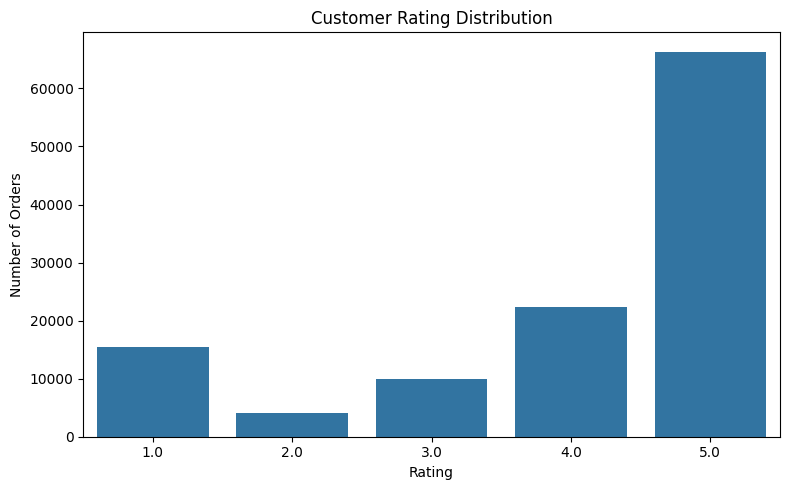

In [146]:
# Rating Distribution
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="rating",
    order=sorted(df["rating"].unique())
)
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()


## 2. Feature Distribution

Analyze the main Model 3 numerical variables, where available:

- Age
- Price
- Quantity
- Discount
- Stock
- Delivery Delay
- Payment Value
- Other engineered numerical features


Available numerical features:
['price', 'payment_value', 'freight_value']


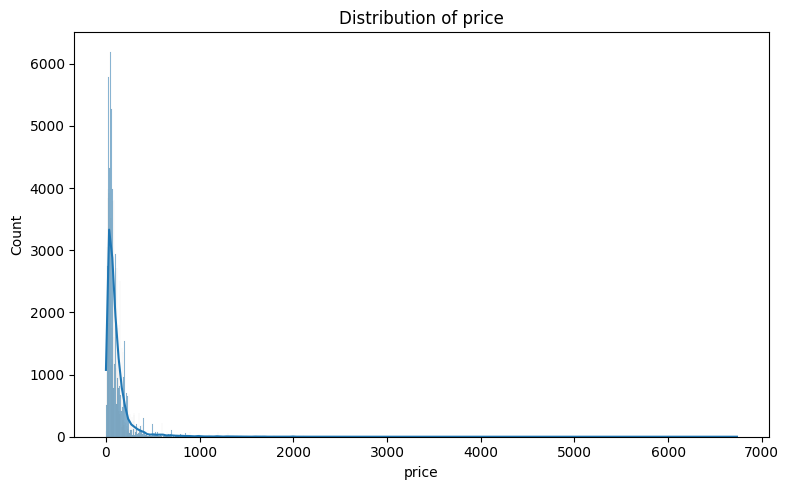

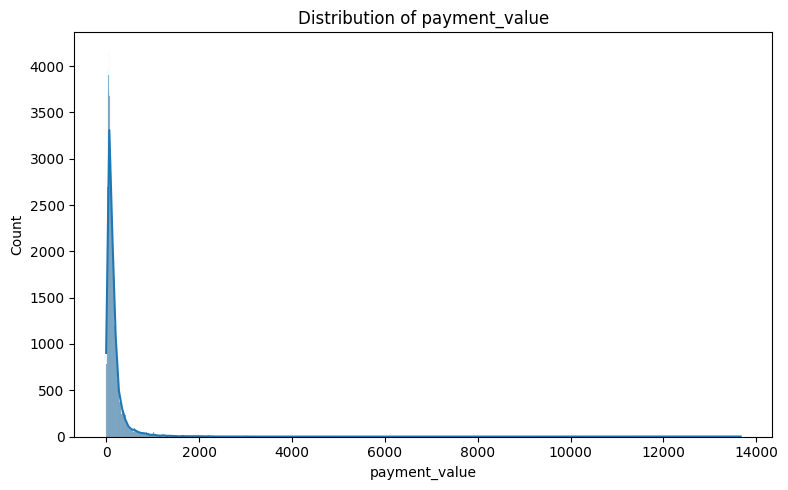

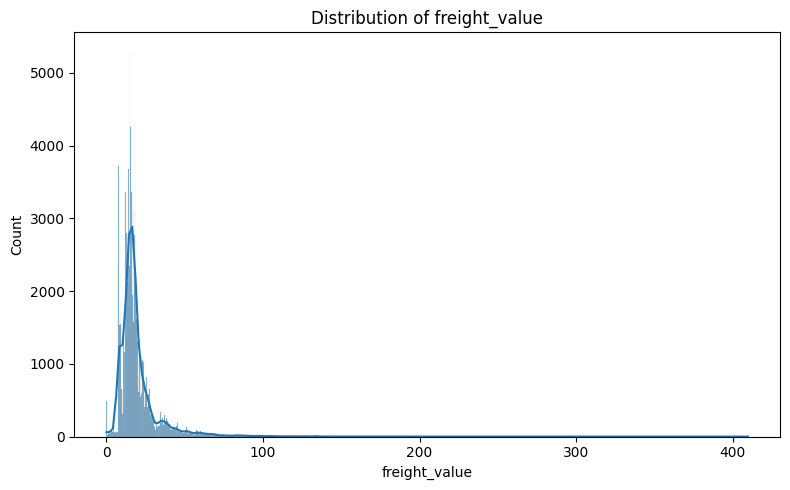

In [147]:
# Select important numerical features that actually exist in the dataset
feature_candidates = [
    "age",
    "customer_age",
    "price",
    "quantity",
    "discount",
    "discount_percent",
    "stock",
    "stock_before_sale",
    "delivery_delay",
    "payment_value",
    "freight_value",
    "price_gap"
]

available_numeric = [
    c for c in feature_candidates
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
]

print("Available numerical features:")
print(available_numeric)

for col in available_numeric:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


### EDA Insight — Feature Distribution

For every numerical feature, the histogram helps us understand its range, concentration, and possible outliers.

These distributions are important before regression because:
- strongly skewed variables may need transformation or careful interpretation;
- extreme values can affect Linear Regression;
- scaling will be handled inside the ML pipeline rather than manually before the train/test split.


## 3. Feature vs Target — Rating

we calculate **Mean Rating** for each group.



In [148]:
def mean_rating_by_group(column, min_count=30):
    if column not in df.columns:
        return None

    result = (
        df.groupby(column, observed=True)["rating"]
          .agg(["mean", "count"])
          .query("count >= @min_count")
          .sort_values("mean", ascending=False)
    )
    return result.rename(columns={"mean": "mean_rating"})

# Category
category_col = next(
    (c for c in ["category", "product_category_name_english"]
     if c in df.columns),
    None
)

if category_col:
    print(f"Mean Rating by {category_col}:")
    display(mean_rating_by_group(category_col).head(15))

# Sales channel
channel_col = next(
    (c for c in ["sales_channel", "channel", "Sales_Channel"]
     if c in df.columns),
    None
)

if channel_col:
    print(f"Mean Rating by {channel_col}:")
    display(mean_rating_by_group(channel_col))

# Age groups
age_col = next(
    (c for c in ["age", "customer_age"]
     if c in df.columns and pd.api.types.is_numeric_dtype(df[c])),
    None
)

if age_col:
    temp = df[[age_col, "rating"]].dropna().copy()
    temp["age_group"] = pd.cut(
        temp[age_col],
        bins=[0, 18, 25, 35, 45, 55, 65, 120],
        labels=["<=18", "19-25", "26-35", "36-45", "46-55", "56-65", "65+"],
        include_lowest=True
    )

    age_rating = (
        temp.groupby("age_group", observed=True)["rating"]
            .agg(["mean", "count"])
            .rename(columns={"mean": "mean_rating"})
    )

    print("Mean Rating by Age Group:")
    display(age_rating)

# Discount groups
discount_col = next(
    (c for c in ["discount_percent", "discount", "discount_percentage"]
     if c in df.columns and pd.api.types.is_numeric_dtype(df[c])),
    None
)

if discount_col:
    temp = df[[discount_col, "rating"]].dropna().copy()
    temp["discount_group"] = pd.qcut(
        temp[discount_col],
        q=5,
        duplicates="drop"
    )

    discount_rating = (
        temp.groupby("discount_group", observed=True)["rating"]
            .agg(["mean", "count"])
            .rename(columns={"mean": "mean_rating"})
    )

    print("Mean Rating by Discount Group:")
    display(discount_rating)

# Stock groups
stock_col = next(
    (c for c in ["stock_before_sale", "stock", "Stock"]
     if c in df.columns and pd.api.types.is_numeric_dtype(df[c])),
    None
)

if stock_col:
    temp = df[[stock_col, "rating"]].dropna().copy()
    temp["stock_group"] = pd.qcut(
        temp[stock_col],
        q=4,
        duplicates="drop"
    )

    stock_rating = (
        temp.groupby("stock_group", observed=True)["rating"]
            .agg(["mean", "count"])
            .rename(columns={"mean": "mean_rating"})
    )

    print("Mean Rating by Stock Group:")
    display(stock_rating)


Mean Rating by product_category_name_english:


,mean_rating,count
product_category_name_english,,
books_general_interest,4.438503,561
books_imported,4.419355,62
flowers,4.419355,31
costruction_tools_tools,4.415842,101
books_technical,4.375465,269
food_drink,4.324138,290
small_appliances_home_oven_and_coffee,4.320513,78
luggage_accessories,4.295945,1159
fashion_sport,4.258065,31


# Visual: Top 10 Product Categories by Mean Rating

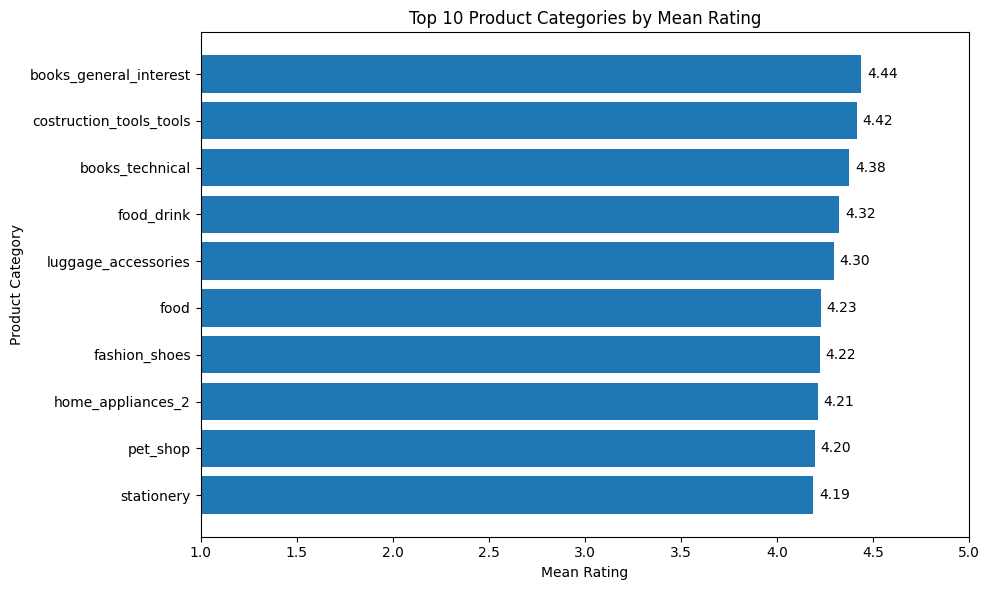

In [149]:

if category_col:

    # Calculate mean rating + number of ratings per category
    category_plot = (
        df.groupby(category_col, observed=True)["rating"]
          .agg(["mean", "count"])
          .rename(columns={"mean": "mean_rating", "count": "rating_count"})
    )

    # Keep only categories with enough ratings
    category_plot = (
        category_plot[category_plot["rating_count"] >= 100]
        .sort_values("mean_rating", ascending=False)
        .head(10)
        .sort_values("mean_rating", ascending=True)
    )

    # Plot
    plt.figure(figsize=(10, 6))

    bars = plt.barh(
        category_plot.index,
        category_plot["mean_rating"]
    )

    plt.title("Top 10 Product Categories by Mean Rating")
    plt.xlabel("Mean Rating")
    plt.ylabel("Product Category")

    # Rating range
    plt.xlim(1, 5)

    # Add rating value at the end of each bar
    for bar, value in zip(bars, category_plot["mean_rating"]):
        plt.text(
            value + 0.03,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center"
        )

    plt.tight_layout()
    plt.show()

# Visual: Mean Rating by Payment Type

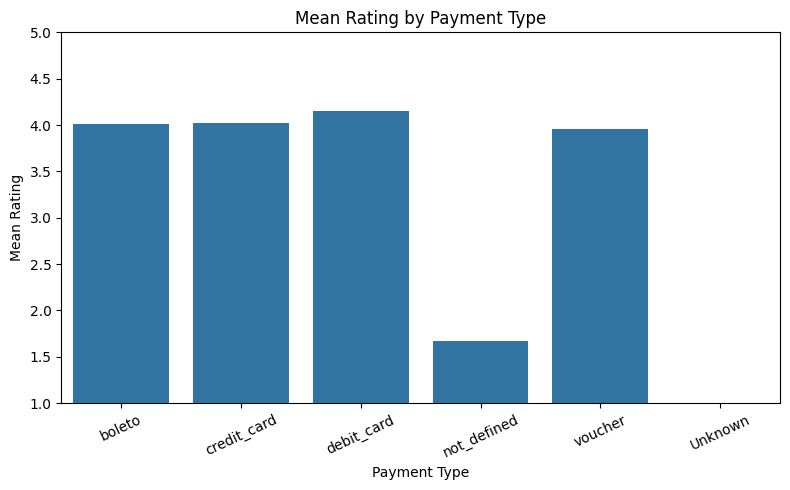

In [150]:


payment_col = "payment_type"

payment_plot = (
    df.groupby(payment_col, observed=True)["rating"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=payment_plot.index,
    y=payment_plot.values
)

plt.title("Mean Rating by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Mean Rating")
plt.ylim(1, 5)
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

# Visual: Mean Rating by Freight Value Group

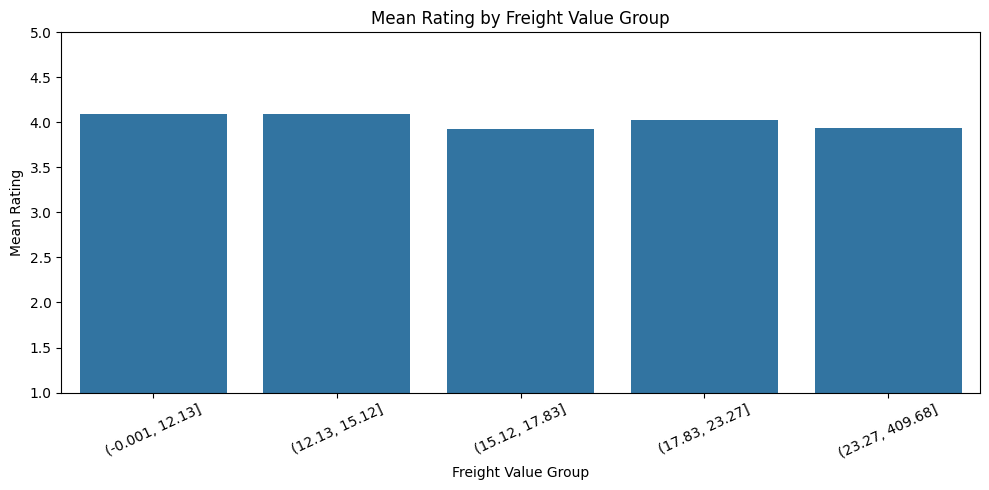

In [151]:


temp = df[["freight_value", "rating"]].dropna().copy()

temp["freight_group"] = pd.qcut(
    temp["freight_value"],
    q=5,
    duplicates="drop"
)

freight_rating = (
    temp.groupby("freight_group", observed=True)["rating"]
        .mean()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=freight_rating.index.astype(str),
    y=freight_rating.values
)

plt.title("Mean Rating by Freight Value Group")
plt.xlabel("Freight Value Group")
plt.ylabel("Mean Rating")
plt.ylim(1, 5)
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

# Visual: Mean Rating by Product Size Category

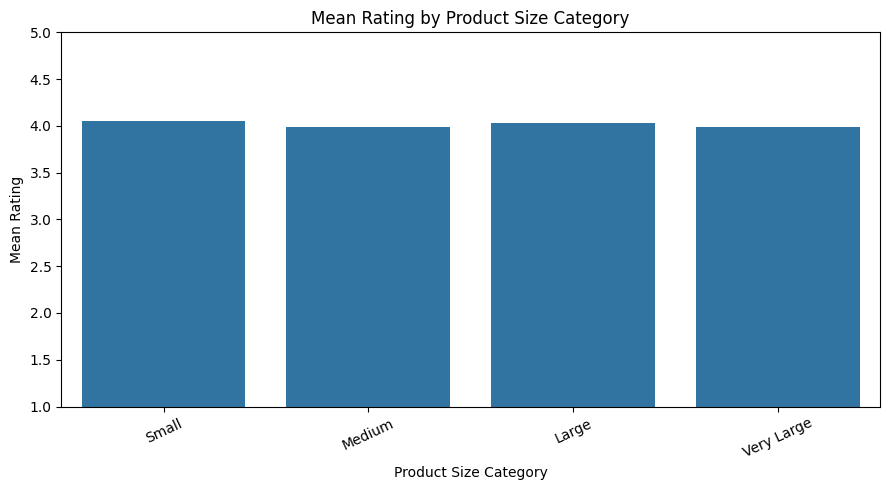

In [152]:


size_col = "product_size_category"

size_rating = (
    df.groupby(size_col, observed=True)["rating"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=size_rating.index,
    y=size_rating.values
)

plt.title("Mean Rating by Product Size Category")
plt.xlabel("Product Size Category")
plt.ylabel("Mean Rating")
plt.ylim(1, 5)
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

## 4. Correlation Analysis

We analyze the correlation between `rating` and numerical variables.

The purpose is to identify variables with stronger linear relationships with customer rating.


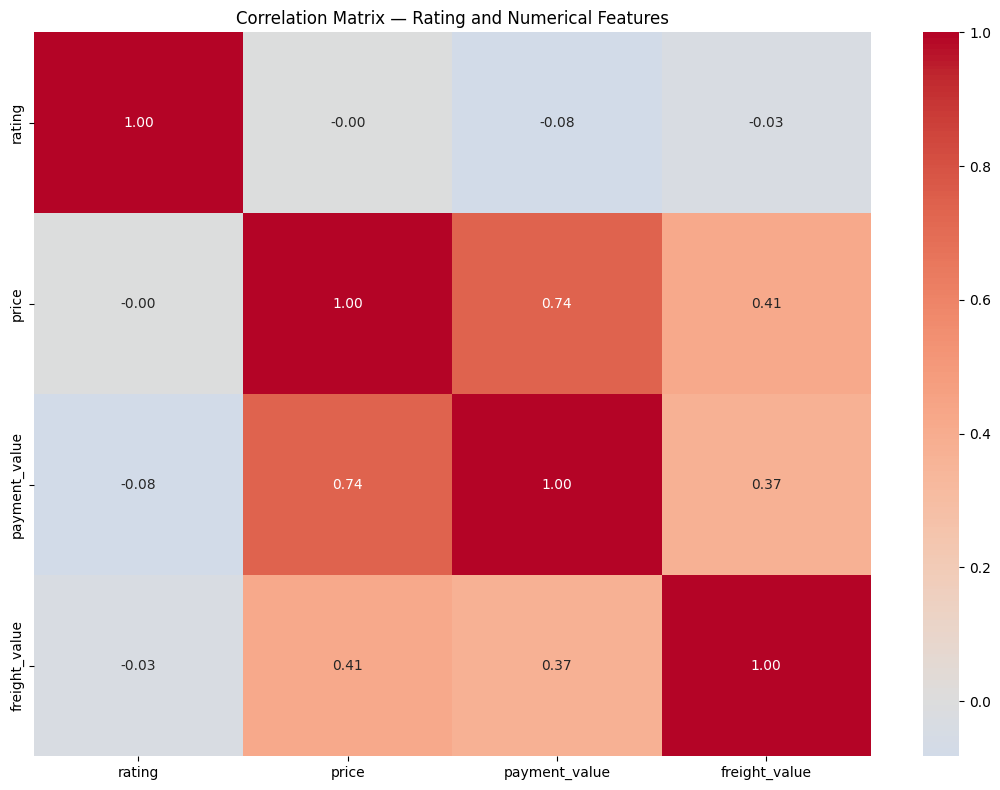

Correlation with Rating:


,correlation_with_rating
payment_value,-0.082325
freight_value,-0.033888
price,-0.001631


In [153]:
corr_candidates = [
    c for c in [
        "rating",
        "age",
        "customer_age",
        "price",
        "quantity",
        "discount",
        "discount_percent",
        "stock",
        "stock_before_sale",
        "delivery_delay",
        "payment_value",
        "freight_value",
        "price_gap"
    ]
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
]

corr_matrix = df[corr_candidates].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix — Rating and Numerical Features")
plt.tight_layout()
plt.show()

print("Correlation with Rating:")
display(
    corr_matrix["rating"]
    .drop("rating")
    .sort_values(key=abs, ascending=False)
    .to_frame("correlation_with_rating")
)


### EDA Insight — Correlation

- Positive correlation means the variables tend to increase together.
- Negative correlation means higher values of the feature tend to be associated with lower ratings.
- A value close to zero indicates a weak **linear** relationship.
- Correlation does not prove causation.
- For Model 3, this analysis is especially useful for understanding the Linear Regression baseline.


## 5. Time Analysis

If an order date/time column exists, we analyze:
- Average rating over time
- Monthly rating patterns
- Weekday rating patterns


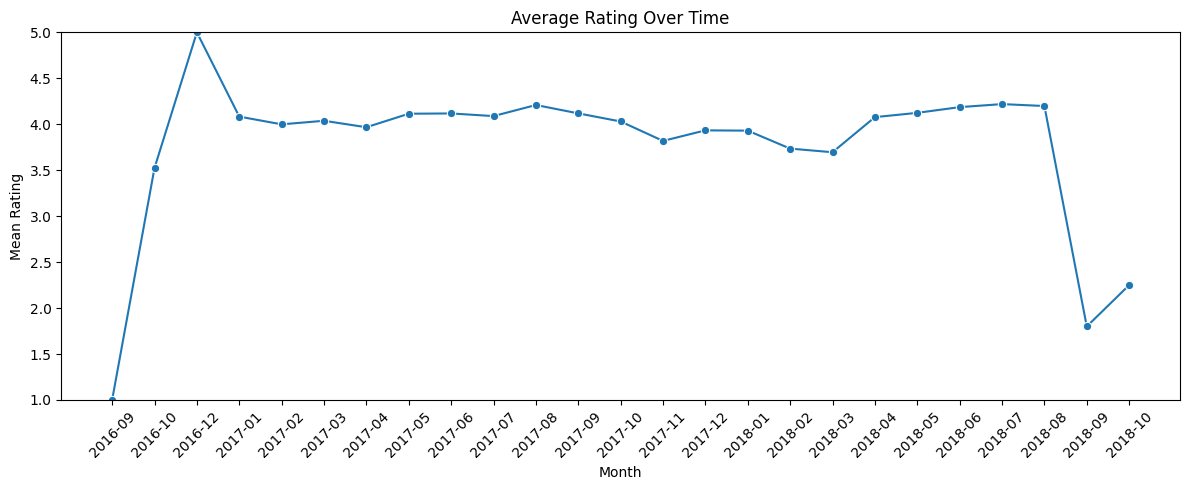

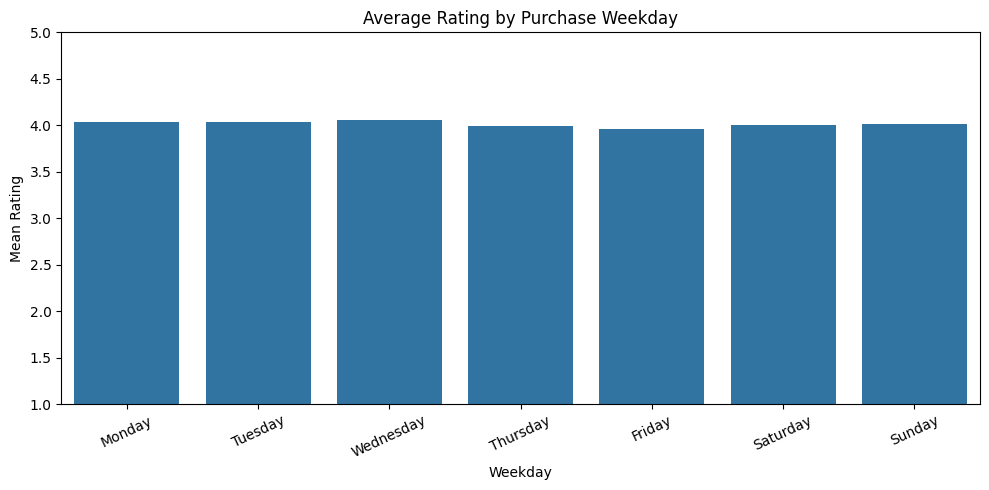

In [154]:
date_col = next(
    (c for c in [
        "order_date",
        "order_purchase_timestamp",
        "Order_Date"
    ] if c in df.columns),
    None
)

if date_col:
    time_df = df[[date_col, "rating"]].copy()
    time_df[date_col] = pd.to_datetime(time_df[date_col], errors="coerce")
    time_df = time_df.dropna(subset=[date_col])

    time_df["month"] = time_df[date_col].dt.to_period("M").astype(str)
    time_df["weekday"] = time_df[date_col].dt.day_name()

    monthly_rating = time_df.groupby("month")["rating"].mean()

    plt.figure(figsize=(12, 5))
    sns.lineplot(
        x=monthly_rating.index,
        y=monthly_rating.values,
        marker="o"
    )
    plt.title("Average Rating Over Time")
    plt.xlabel("Month")
    plt.ylabel("Mean Rating")
    plt.ylim(1, 5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    weekday_order = [
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ]

    weekday_rating = (
        time_df.groupby("weekday")["rating"]
        .mean()
        .reindex(weekday_order)
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=weekday_rating.index,
        y=weekday_rating.values
    )
    plt.title("Average Rating by Purchase Weekday")
    plt.xlabel("Weekday")
    plt.ylabel("Mean Rating")
    plt.ylim(1, 5)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()
else:
    print("No suitable date column was found; time analysis was skipped.")


### EDA Insight — Time Analysis

- Look for months or weekdays with noticeably higher/lower average ratings.



# Linear Regression

In [155]:
# Model 3 feature preparation
model3_features = [
    # Delivery — most important predictors
    "delivery_days",
    "expected_delivery_days",
    "delivery_delay_days",
    "is_delayed",
    "delivery_speed_ratio",
    "early_delivery",

    # Pricing
    "price",
    "shipping_price_ratio",
    "average_installment_value",
    "total_cost",

    # Category / payment / status
    "product_category_name_english",
    "payment_type",
    "order_status",

    # Time
    "purchase_month",
    "purchase_weekday",
    "purchase_hour",
    "is_weekend",
    "purchase_quarter",
    "approval_time_hours",
    "shipping_preparation_hours",

    # Product
    "product_volume",
    "product_density",
    "product_size_category",
    "large_product",

    # Order behavior
    "items_per_order",
    "same_state",
    "night_purchase",
    "has_review_comment",
    "has_multiple_photos",
    "multiple_installments",
]

model3_features = [
    c for c in model3_features
    if c in df.columns and c != "rating"
]

X = df[model3_features].copy()
y = df["rating"].astype(float)

X = X.replace([np.inf, -np.inf], np.nan)

print("Model 3 features:")
print(model3_features)
print("X shape:", X.shape)
print("y shape:", y.shape)

Model 3 features:
['delivery_days', 'expected_delivery_days', 'delivery_delay_days', 'is_delayed', 'delivery_speed_ratio', 'early_delivery', 'price', 'shipping_price_ratio', 'average_installment_value', 'total_cost', 'product_category_name_english', 'payment_type', 'order_status', 'purchase_month', 'purchase_weekday', 'purchase_hour', 'is_weekend', 'purchase_quarter', 'approval_time_hours', 'shipping_preparation_hours', 'product_volume', 'product_density', 'product_size_category', 'large_product', 'items_per_order', 'same_state', 'night_purchase', 'has_review_comment', 'has_multiple_photos', 'multiple_installments']
X shape: (118146, 30)
y shape: (118146,)


In [156]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['delivery_days', 'expected_delivery_days', 'delivery_delay_days', 'is_delayed', 'delivery_speed_ratio', 'early_delivery', 'price', 'shipping_price_ratio', 'average_installment_value', 'total_cost', 'purchase_month', 'purchase_weekday', 'purchase_hour', 'is_weekend', 'purchase_quarter', 'approval_time_hours', 'shipping_preparation_hours', 'product_volume', 'product_density', 'large_product', 'items_per_order', 'same_state', 'night_purchase', 'has_review_comment', 'has_multiple_photos', 'multiple_installments']
Categorical features: ['product_category_name_english', 'payment_type', 'order_status', 'product_size_category']


In [157]:
for col in numeric_features:
    n_inf = np.isinf(X_train[col]).sum()
    if n_inf > 0:
        print(col, "->", n_inf, "infinite values")

In [158]:
X = df[model3_features].copy()
y = df["rating"].astype(float)

# Replace infinite values with NaN so the imputer can handle them
X = X.replace([np.inf, -np.inf], np.nan)

print("Model 3 features:")
print(model3_features)
print("X shape:", X.shape)
print("y shape:", y.shape)

Model 3 features:
['delivery_days', 'expected_delivery_days', 'delivery_delay_days', 'is_delayed', 'delivery_speed_ratio', 'early_delivery', 'price', 'shipping_price_ratio', 'average_installment_value', 'total_cost', 'product_category_name_english', 'payment_type', 'order_status', 'purchase_month', 'purchase_weekday', 'purchase_hour', 'is_weekend', 'purchase_quarter', 'approval_time_hours', 'shipping_preparation_hours', 'product_volume', 'product_density', 'product_size_category', 'large_product', 'items_per_order', 'same_state', 'night_purchase', 'has_review_comment', 'has_multiple_photos', 'multiple_installments']
X shape: (118146, 30)
y shape: (118146,)


In [159]:
# Linear Regression

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

model_comparison = pd.DataFrame([{
    "Model": "Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}])

display(model_comparison.round(4))


,Model,MAE,RMSE,R2
0,Linear Regression,0.9624,1.2361,0.2211


# Decision Tree

In [160]:
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=RANDOM_STATE))
])

tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

model_comparison = pd.concat([
    model_comparison,
    pd.DataFrame([{
        "Model": "Decision Tree",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }])
], ignore_index=True)

display(model_comparison.round(4))


,Model,MAE,RMSE,R2
0,Linear Regression,0.9624,1.2361,0.2211
1,Decision Tree,0.8528,1.4669,-0.0970


# Random Forest

In [ ]:
forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=RANDOM_STATE))
])

forest_model.fit(X_train, y_train)
y_pred = forest_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

model_comparison = pd.concat([
    model_comparison,
    pd.DataFrame([{
        "Model": "Random Forest",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }])
], ignore_index=True)

display(model_comparison.round(4))


# KNN Regressor

In [ ]:
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", KNeighborsRegressor())
])

knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

model_comparison = pd.concat([
    model_comparison,
    pd.DataFrame([{
        "Model": "KNN",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }])
], ignore_index=True)

display(model_comparison.round(4))


# Model Comparison

### Insight
- **What happened?** Compare the four regression algorithms (Linear Regression, Decision Tree, Random Forest, KNN) trained on the same train/test split using MAE, RMSE, and R².
- **ML meaning:** Lower MAE/RMSE and higher R² indicate a model that predicts the customer rating more accurately and explains more of the variance in the target.
- **Business meaning:** A more accurate rating-prediction model lets the business flag at-risk orders (likely to receive low ratings) before the customer actually reviews them.
- **Action / recommendation:** Move forward with the best-performing algorithm and tune it further with GridSearchCV instead of tuning all four models.
- **Limitation:** Results depend on this specific train/test split and the engineered features available; performance may shift with different feature sets or more data.

In [ ]:
model_comparison_sorted = model_comparison.sort_values(
    by=["MAE", "RMSE"], ascending=[True, True]
).reset_index(drop=True)

display(model_comparison_sorted.round(4))


# Winner Selection

In [ ]:
# Winner = lowest MAE (primary criterion), with RMSE and R2 as supporting evidence
winner_row = model_comparison_sorted.iloc[0]
winner_name = winner_row["Model"]

print(f"Best model based on MAE/RMSE/R2: {winner_name}")
display(winner_row.to_frame().T.round(4))

models_dict = {
    "Linear Regression": linear_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model,
    "KNN": knn_model
}

winner_model = models_dict[winner_name]


# GridSearchCV — Tuning the Winner Only

In [ ]:
# Define the parameter grid depending on which model won
# (Only the winner is tuned — not all four models)

param_grids = {
    "Decision Tree": {
        "regressor__max_depth": [5, 10, None],
        "regressor__min_samples_split": [2, 5],
        "regressor__min_samples_leaf": [1, 2]
    },
    "Random Forest": {
        "regressor__n_estimators": [100, 200],
        "regressor__max_depth": [5, 10, None],
        "regressor__min_samples_split": [2, 5]
    },
    "KNN": {
        "regressor__n_neighbors": [3, 5, 7, 9],
        "regressor__weights": ["uniform", "distance"]
    },
    "Linear Regression": {
        "regressor__fit_intercept": [True, False]
    }
}

param_grid = param_grids[winner_name]

grid = GridSearchCV(
    winner_model,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(f"Best params for {winner_name}:", grid.best_params_)
print(f"Best CV RMSE: {-grid.best_score_:.4f}")

tuned_model = grid.best_estimator_


In [ ]:
# Evaluate the tuned winner on the test set
y_pred_tuned = tuned_model.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

model_comparison_final = pd.concat([
    model_comparison,
    pd.DataFrame([{
        "Model": f"{winner_name} (Tuned)",
        "MAE": mae_tuned,
        "RMSE": rmse_tuned,
        "R2": r2_tuned
    }])
], ignore_index=True)

model_comparison_final["Tuned"] = model_comparison_final["Model"].str.contains("Tuned")
model_comparison_final["Selected"] = model_comparison_final["Model"] == f"{winner_name} (Tuned)"

display(model_comparison_final.round(4))


In [ ]:
print("Categorical features:", categorical_features)
print()
for col in categorical_features:
    print(col, "->", X_train[col].nunique(), "unique values")

In [ ]:
print([c for c in df.columns if "delay" in c.lower() or "delivery" in c.lower()])
print([c for c in df.columns if "discount" in c.lower() or "price" in c.lower()])
print([c for c in df.columns if "age" in c.lower() or "quantity" in c.lower() or "stock" in c.lower()])
print([c for c in df.columns if "channel" in c.lower() or "courier" in c.lower() or "status" in c.lower()])